## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Will Morales

**Date:** 10/1/26

In [20]:
#Q1 referenced the class slides
#1 Regression predicts a number. Classification predicts a category.
#2 A confusion table or matrix counts predictions by actual class and predicted class. The diagonal cells are correct predictions and the off diagonal cells are misclassifications. The table helps us see where the model does well versus poorly.
#3 SSE is the sum of squared error. For each observation, the residual is the actual value minus the prediction, and SSE adds up the squared residuals. It quantifies the total size of the model's prediction errors.
#4 Overfitting is when a model fits the noise in the training data. Underfitting is when the model is too simple, so it gives nearly the same prediction for every observation.
#5 Choosing k by training error would pick a tiny k and overfit. Splitting the data lets me fit on the training set and check the accuracy or SSE on data the model hasn't seen, so we pick the k that generalizes best.
#6 A class label is easy to report, but it hides uncertainty, since a very tight vote looks the same as a landslide. A probability distribution shows hiw confident the model is and lets us pick a cutoff when errors cost different amounts, but it's tougher with a small k.



In [21]:
#Q2 imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [22]:
from google.colab import files
uploaded = files.upload()

Saving land_mines.csv to land_mines (1).csv


In [23]:
#1 EDA
df = pd.read_csv('land_mines.csv')
df.head()
print(df.shape)
print(df.isna().sum())
print(df[["voltage", "height", "soil"]].describe())

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


In [24]:
#2 Split into 2
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.5, random_state=65, stratify=y)
#test size is 0.5 because split in half; stratify helps them be more even

2 0.46745562130177515


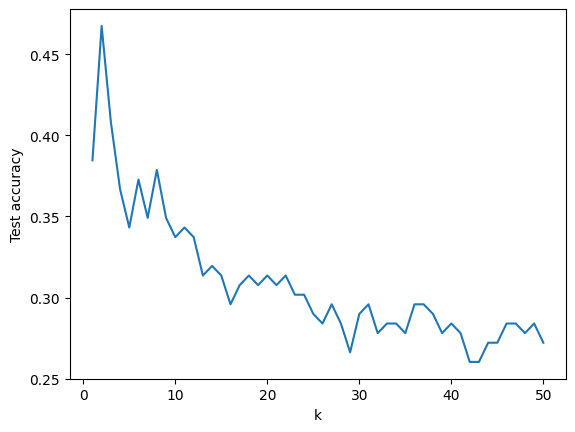

In [25]:
#3 building the model
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scaling first
X_test_scaled = scaler.transform(X_test)         # apply same scaling to test

ks = np.arange(1, 51)
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    test_acc.append(model.score(X_test_scaled, y_test))
    train_acc.append(model.score(X_train_scaled, y_train))

k_star = int(ks[np.argmax(test_acc)])
print(k_star, max(test_acc))

plt.plot(ks, test_acc)
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.show()
#How I selected K: #Chose 50 as the largest K to try because the slides used that but it also fits here because it is way larger than the best k but way smaller than 169.

In [26]:
#4 Confusion table
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Building the table
print(pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"]))

# Accuracy test
print(np.mean(y_pred == y_test))


Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
0.46745562130177515


In [27]:
#5
# The model can look good for one type of mine and still make a lot of mistakes.
# For example, it finds 27 of the 36 real type 1 mines (75%), which soujnds
# strong. But it predicted type 1 a total of 67 times, so only 27 of those
# predictions (about 40%) were right. Many type 3, 4, and 5 mines get called
# type 1. Overall accuracy is only about 47%, so mistakes are pretty common.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]